# Week 3 — 언제 바꿀 것인가: 상태를 보고 하는 정비

**Business Analytics · 산업공학과 4학년 · 2026 · Backblaze 데이터센터 하드디스크 기록**

하드디스크는 쓰는 동안 고장 난다. 고장 난 뒤에 바꿀 수도 있고, 오래된 것부터 미리 바꿀 수도 있고, 상태가 나빠진 것부터 미리 바꿀 수도 있다. 이 장은 데이터센터가 매일 남긴 디스크 기록으로 2026년 1분기 90일 동안 교체 규칙을 도입했다면 비용이 어떻게 달라졌을지 비교한다.

> **실습본이다.** 첫 셀(데이터 준비)을 빼고 코드 셀이 전부 비어 있다. 각 셀의 주석이 무엇을
> 할지 알려 주고, 바로 위 지시문이 그 이유를 설명한다. 수업 중 교수와 함께 한 셀씩 타이핑해
> 채운다. 코드가 채워진 판은 따로 배포하지 않으므로, 수업이 끝나면
> **"파일 → Drive에 사본 저장"** 으로 직접 채운 노트북을 각자 보관한다.

> **120분 수업 운영안.** 데이터 읽기 15분 → 문제·분석 계획 10분 → 관측 기간과 고장률 15분 → 나이별 비교 10분 → 휴식 5분 → 신호와 선행 시간 20분 → 교체 대상·예방 고장 20분 → 비용 비교·해석 20분 → 마무리 5분. 7-5의 구간별 반복 계산은 교수자 시연으로 읽고, 기준값을 여러 개 비교하는 코딩은 준비 코드를 제공하는 60분·7과제 랩에서 한다. 파이썬 조건·반복문과 2주차의 집계·날짜 계산을 배운 학생 기준이다.

## 1. 데이터

Backblaze는 미국의 클라우드 저장 서비스다. 창고에 하드디스크 수십만 개를 꽂아 놓고 쓴다. 매일 디스크마다 그날의 상태를 기록해 두고, 석 달마다 그 기록을 공개한다. 이 장은 2026년 1월 1일부터 3월 31일까지 90일 동안의 기록을 쓴다. 디스크가 너무 많아 이 과목에서 6만 개를 무작위로 뽑았다. 디스크 하나에 하루 한 번 기록한다. 이 하루치 기록 하나를 데이터포인트라 부른다. 90일 내내 있던 디스크는 데이터포인트가 90개이고, 전체는 약 523만 개다.

데이터포인트 하나에는 날짜, 디스크 번호, 그날 고장 났는지, 그리고 디스크 안에서 측정된 숫자 몇 개가 있다. 이 숫자들을 SMART(Self-Monitoring, Analysis and Reporting Technology)라 부른다. 하나는 "지금까지 몇 시간 켜져 있었나"다. 다른 값은 읽거나 쓰는 데 문제가 있는 저장 위치(불량 섹터)와 오류 등을 기록한다. 이 장에서는 네 지표가 0보다 큰 상태를 교체 후보를 찾는 신호로 쓴다. 값이 0이라고 모든 고장 가능성이 없는 것은 아니다. 디스크가 고장 나서 바꾸면 그날 데이터포인트에 `failure = 1`이 적히고 그 뒤로는 데이터포인트가 없다. 운영 중에 자동으로 쌓인 기록이다.

미리 바꾸는 데 드는 비용과 고장 났을 때 드는 비용은 기록에 없다. 이 두 비용이 있어야 어느 규칙이 싼지 정할 수 있으므로, 9절에서 값을 정해 넣고 결론이 두 비용에 따라 얼마나 달라지는지도 본다.

SMART 열의 원래 이름은 `smart_9_raw`처럼 번호라서 무슨 뜻인지 보이지 않는다. 처음부터 뜻이 보이는 이름으로 바꿔 쓴다.

| 열 (원래 이름) | 의미 |
|---|---|
| `date` | 기록 날짜 |
| `serial_number` | 디스크 번호 |
| `model`, `capacity_tb` | 모델, 용량 |
| `failure` | 그날 고장으로 바꿨으면 1 |
| `power_on_hours` (smart_9) | 지금까지 켜져 있던 시간 (시간) |
| `reallocated_sectors` (smart_5) | 재할당된 불량 섹터 수 |
| `uncorrectable_errors` (smart_187) | 정정 불가 오류 보고 수 |
| `pending_sectors` (smart_197) | 대기 중 불량 섹터 수 |
| `offline_uncorrectable` (smart_198) | 오프라인 정정 불가 섹터 수 |
| `command_timeouts` (smart_188) | 명령 시간 초과 수 (이 장에서는 쓰지 않는다) |

데이터 확보(다운로드·캐시)는 `balab.load`가 처리한다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import os
import sys
for _p in (".", "..", "../.."):
    if os.path.exists(os.path.join(_p, "balab.py")):
        sys.path.insert(0, _p); break
else:
    !wget -q https://raw.githubusercontent.com/BALAB-PKNU/bizanalytics/main/balab.py

from balab import load
bb = load("backblaze_2026")
bb = bb.rename(columns={"smart_9_raw": "power_on_hours",            # 지금까지 켜져 있던 시간 (시간)
                        "smart_5_raw": "reallocated_sectors",       # 재할당된 불량 섹터 수
                        "smart_187_raw": "uncorrectable_errors",    # 정정 불가 오류 보고 수
                        "smart_188_raw": "command_timeouts",        # 명령 시간 초과 수
                        "smart_197_raw": "pending_sectors",         # 대기 중 불량 섹터 수
                        "smart_198_raw": "offline_uncorrectable"})  # 오프라인 정정 불가 섹터 수

## 2. 데이터 탐색

분석에 들어가기 전에 데이터포인트 하나가 무엇인지, 기간이 얼마인지, 디스크가 몇 개인지, 고장이 몇 건인지 확인한다.

**2-1. 디스크 한 개가 기록에 어떤 모습으로 나타나는지 확인해 보자.**

같은 디스크 번호가 반복되는지, 날짜가 어떻게 바뀌는지 읽는다. 표를 담은 `bb`를 코드 셀의 마지막 줄에 쓰면 표가 출력된다.

In [2]:
bb # 2-1. 데이터프레임을 이름만 쳐서 출력한다

,date,serial_number,model,capacity_tb,failure,reallocated_sectors,power_on_hours,uncorrectable_errors,command_timeouts,pending_sectors,offline_uncorrectable
0,2026-01-01,00ac486b9bec0010,DELLBOSS VD,0.5,0,-1,-1,-1,-1,-1,-1
1,2026-01-02,00ac486b9bec0010,DELLBOSS VD,0.5,0,-1,-1,-1,-1,-1,-1
2,2026-01-03,00ac486b9bec0010,DELLBOSS VD,0.5,0,-1,-1,-1,-1,-1,-1
3,2026-01-04,00ac486b9bec0010,DELLBOSS VD,0.5,0,-1,-1,-1,-1,-1,-1
4,2026-01-05,00ac486b9bec0010,DELLBOSS VD,0.5,0,-1,-1,-1,-1,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...
5227848,2026-03-27,f58fde45a2870010,DELLBOSS VD,0.5,0,-1,-1,-1,-1,-1,-1
5227849,2026-03-28,f58fde45a2870010,DELLBOSS VD,0.5,0,-1,-1,-1,-1,-1,-1
5227850,2026-03-29,f58fde45a2870010,DELLBOSS VD,0.5,0,-1,-1,-1,-1,-1,-1
5227851,2026-03-30,f58fde45a2870010,DELLBOSS VD,0.5,0,-1,-1,-1,-1,-1,-1


> 데이터포인트 하나는 디스크 하나의 하루 상태다. 같은 디스크가 날마다 한 번씩 나온다.

데이터포인트 수를 세면 디스크 개수가 아니라 디스크의 날수가 나온다. 무엇을 셀 때든 디스크를 세는 것인지 디스크의 날을 세는 것인지부터 정한다.

**2-2. 이 기록으로 어느 기간의 고장을 살펴볼 수 있는지 확인해 보자.**

기록 날짜인 `date`의 가장 이른 값과 늦은 값을 구한다. `min`과 `max`가 각각 첫날과 마지막 날을 알려 준다.

In [6]:
# 2-2. date의 최소와 최대 (min, max)
print('최소값: ', bb['date'].min())
print('최대값: ', bb['date'].max())

최소값:  2026-01-01 00:00:00
최대값:  2026-03-31 00:00:00


> 2026년 1월 1일부터 3월 31일까지, 90일이다. 디스크 하나가 90일 내내 있었다면 데이터포인트가 90개다.

**2-3. 모든 디스크를 같은 기간 동안 관측했는지 확인해 보자.**

중간에 들어오거나 관측이 끝난 디스크가 있으면 디스크 수만으로 고장 빈도를 비교하기 어렵다.

`serial_number`에 `value_counts`를 적용해 디스크별 기록 수를 `days`에 담는다. 하루 한 기록이므로 이 값은 관측된 날수다. `describe`로 개수·최솟값·중앙값·최댓값을 읽는다.

In [10]:
# 2-3. 디스크별 관측된 날수를 days에 담고 요약한다 (value_counts, describe)
print('총 디스크 수 :', bb['serial_number'].nunique())

총 디스크 수 : 60000


In [12]:
days =bb['serial_number'].value_counts()
days.describe() # 시리얼번호 별 날짜 기록일의 통계량

,count
count,60000.000000
mean,87.130883
std,13.231745
min,1.000000
25%,90.000000
50%,90.000000
75%,90.000000
max,90.000000


> 디스크 6만 개다. 날수는 최대 90일이고 하루뿐인 디스크도 있다.

중간에 기록이 시작되거나 끝나는 디스크도 있다. 고장 외의 이유로 관측이 끝났을 수도 있다. 디스크마다 있던 날수가 다르다는 사실을 5절에서 다시 쓴다.

**2-4. 상태를 확인할 수 있는 기록을 골라 보자.**

SMART를 보고하지 않는 장치의 값은 이 자료에서 −1로 표시되어 있다. 누적 가동 시간도 없는 기록은 나이와 상태를 비교할 대상에서 제외한다. 다른 신호의 미보고 값도 정상이라는 뜻은 아니다.

`power_on_hours`가 0 이상인 행을 조건 필터로 고르고 `copy`로 사본을 만들어 `bb`에 다시 담는다. `len`으로 데이터포인트 수, `nunique`로 서로 다른 디스크 수를 확인한다.

In [17]:
# 2-4. power_on_hours가 0 이상인 데이터포인트만 남긴 사본을 bb에 되담는다 (조건 필터, copy). 데이터포인트 수(len)와 디스크 수(nunique)
bb = bb[bb['power_on_hours'] >= 0].copy()
len(bb), bb['serial_number'].nunique()


(5221794, 59934)

> 데이터포인트 5,221,794개, 디스크 59,934개가 남는다.

**2-5. 90일 동안 고장이 몇 건 기록됐는지 세어 보자.**

고장 난 날의 데이터포인트에만 `failure`가 1이다. 이 열에 `value_counts`를 적용해 1인 기록의 개수를 읽는다.

In [19]:
# 2-5. failure의 값별 개수 (value_counts)
bb['failure'].value_counts()

,count
failure,
0,5221600
1,194


> 194건이다.

## 3. 풀고자 하는 문제

데이터센터 운영팀은 디스크 6만 개를 굴린다. 디스크가 고장 나면 사람이 가서 갈아 끼워야 한다. 고장 난 디스크의 데이터는 다른 디스크에 복사본이 있어서 잃지는 않지만, 새 디스크에 다시 채워 넣을 때까지는 복사본이 하나 줄어든 채로 돌아간다. 고장 전에 교체를 마치면 고장으로 인한 대응을 줄일 수 있다. 그 대신 아직 멀쩡한 디스크를 버린다. 고장 한 번이 얼마나 비싼지는 회사마다 다르고, 그 차이가 답을 정한다(9절). 팀은 셋 중 하나를 골라야 한다.

- **고장 후 교체** — 미리 바꾸지 않는다. 미리 바꾸는 비용은 없지만 고장을 모두 겪는다.
- **나이 기준 교체** — 켜져 있던 시간이 $T$년을 넘으면 미리 바꾼다.
- **상태 기준 교체** — 불량 섹터 같은 신호가 켜지면 미리 바꾼다.

> ### 이번 주의 의사결정 질문
> **"제시한 고장 후 교체·나이 기준 교체·상태 기준 교체 후보 중 비용 조건에 따라 무엇을 택할 것인가?"**

미리 바꾸는 규칙은 멀쩡한 디스크도 갈아 끼운다. 그 비용이 막아 낸 고장의 비용보다 작아야 이득이다. 그래서 규칙마다 두 가지를 센다. 90일 동안 그 규칙대로 했다면 몇 개를 미리 바꿨을까, 그리고 그중 몇 개가 실제로 고장 날 디스크였을까. 이 둘을 알면 고장 한 번의 비용이 미리 바꾸는 비용의 몇 배를 넘어야 그 규칙이 이득인지 나온다. 무엇을 언제 바꿀지 정하는 이 계산은 설비보전·플랜트 운영·데이터센터 운영 부서가 늘 다루는 문제다.

이 장은 고장 빈도와 나이별 차이를 확인하고(5·6절), 신호의 차이와 관측된 선행 시간을 살펴본다(7절). 이어 규칙별 교체 대상과 예방 가능한 고장을 세고(8절), 비용 조건별 선택을 비교한다(9절).

이 장에 필요한 이론(신뢰도와 위험률, 관측 기간이 다를 때 고장률을 재는 법, 욕조곡선, 미리 바꾸는 것이 이득이 되는 조건, 상태 기준 정비의 조건)은 **[3주차 배경이론 — 고장률과 예방정비](https://balab-pknu.github.io/bizanalytics/theory/week03.html)** 문서에 있다.

## 4. 분석 계획

**질문.** 세 규칙 중 무엇을 택할 것인가.

### 💬 먼저 답해 본다

1. 고장률을 어떻게 재겠는가. 90일 중간에 들어온 디스크는 어떻게 세는가.
2. 상태 기준 교체가 이득이려면 무엇이 확인돼야 하는가. 신호가 고장 당일에야 켜진다면 어떤가.
3. 어떤 규칙이 이득인지는 무엇과 무엇을 비교해서 정하는가.

계산에 쓸 기준은 다음과 같다.

| 항목 | 정의 |
|---|---|
| 고장률 | 고장 난 개수 ÷ 디스크가 있었던 날수의 합(= 데이터포인트 수) × 365. 디스크·년당 고장 빈도로 환산한 값이다(5절). |
| 나이 | 지금까지 켜져 있던 시간을 년으로 바꾼 값 |
| 신호 | 불량 섹터·오류를 세는 값 넷. 0보다 크면 켜진 것 |
| 규칙의 성적 | 이 90일에 규칙을 도입해 미리 교체할 디스크 전체 $n$, 그중 이 기간에 실제 고장이 기록된 디스크 $m$. 처음 관측될 때 이미 조건에 걸린 디스크도 두 집계에 포함한다 |
| 고장 하나당 바꾼 개수 | $n/m$. 고장 한 번의 비용이 미리 바꾸는 비용의 이 배수를 넘으면 그 규칙이 고장 후 교체보다 싸다 |

### 계획

| 계획 | 무엇을 하는가 | 왜 필요한가 | 절 |
|---|---|---|---|
| ① | 고장률을 잰다 | 고장이 얼마나 드문지가 미리 바꾸는 규칙에서 멀쩡한 디스크를 바꾸는 크기를 정한다 | 5절 |
| ② | 나이별 고장률을 낸다 | 나이 기준 교체는 오래된 디스크가 실제로 더 자주 고장 나야 성립한다 | 6절 |
| ③ | 신호가 고장 디스크에서 몇 배 자주 켜지는지, 고장 며칠 전부터 켜지는지 본다 | 상태 기준 교체는 신호가 미리 켜져야 성립한다 | 7절 |
| ④ | 규칙마다 90일 기록에 적용해 $n$, $m$, $n/m$을 센다 | 규칙들을 같은 기준으로 놓고 비교한다 | 8절 |
| ⑤ | 비용 비율을 바꿔 가며 규칙별 총비용을 고장 후 교체와 비교하고 권고한다 | 비율이 정해져야 규칙이 정해진다 | 9절 |

## 5. 계획 ① — 고장이 얼마나 자주 나는가

이 데이터센터에서 디스크가 얼마나 자주 고장 나는지 잰다. 고장이 드물수록 미리 바꾸는 디스크의 대부분은 고장 나지 않을 디스크다.

**5-1. 관측한 디스크 중 고장이 기록된 비율을 계산해 보자.**

먼저 디스크 개수로 나눈 비율을 구한다. 다만 관측 기간이 서로 다르다는 2-3의 결과 때문에, 이 비율을 모든 디스크의 90일 고장 확률로 해석할 수는 없다.

`failure`가 1인 기록의 디스크 번호를 `set`으로 모아 `failed`에 담는다. 집합은 같은 번호를 한 번만 남긴다. 집합의 크기를 전체 고유 디스크 수로 나눠 `rate90`에 담고, 365 ÷ 90을 곱한 단순 연간 환산값도 확인한다.

In [26]:
# 5-1. 고장 디스크 번호를 failed 집합에 담고 고유 디스크 수로 나눈 rate90과 연간 환산값을 확인한다 (조건 필터, set, nunique)
failed = bb[bb['failure']==1]['serial_number'] # 고장이 난 디스크의 시리얼 넘버
total_disk = bb['serial_number'].nunique() # 전체 디스크의 개수(시리얼 넘버의 고유값으로 확인 가능)
rate90 = len(failed)/total_disk
print('총 고장 개수: ',len(failed))
print('90일 기준 하드디스크 고장률 : ',rate90)
print('1년 기준 하드디스크 고장률; ',rate90*365 / 90)

총 고장 개수:  194
90일 기준 하드디스크 고장률 :  0.003236893916641639
1년 기준 하드디스크 고장률;  0.013127403106379982


> 고장 난 디스크는 194개다. 194 ÷ 59,934 = 0.0032이고, 365 ÷ 90을 곱하면 0.0131이다.

첫 값은 90일 동안의 비율이다. 고장률은 기간을 붙여야 뜻이 있고, 보통 1년 기준으로 말하므로 365 ÷ 90을 곱해 1년 기준으로 바꾼 것이 둘째 값이다. 이 계산은 모든 디스크가 90일 내내 있었을 때만 맞다. 2-3에서 본 대로 중간에 들어오거나 고장으로 빠진 디스크가 있으므로, 디스크 수 대신 디스크가 있었던 날수의 합으로 나눈다. 데이터포인트 하나가 디스크의 하루이므로 그 합은 데이터포인트 수다. Backblaze가 발표하는 연간고장률(annualized failure rate, AFR)이 이 방식이다. 디스크 세 개짜리 예로 두 방법의 차이를 본다.

**5-2. 관측한 날수가 다르면 고장 빈도 계산이 얼마나 달라지는지 비교해 보자.**

A는 90일 동안 고장 없이 관측됐고, B는 60일째 고장 났으며, C는 30일 동안 고장 없이 관측됐다. 고장 디스크는 3개 중 1개이고, 관측한 날수의 합은 180디스크·일이다.

고장 1건을 디스크 수로 나눈 값에 365 ÷ 90을 곱한다. 이어 고장 1건을 관측한 날수의 합으로 나누고 365를 곱해 비교한다.

In [27]:
# 5-2. 고장 1건을 디스크 3개와 관측된 180디스크·일로 각각 나눠 1년 단위로 환산한다 (사칙연산)
print('하드디스크 기준 연간 고장률:', (1/3)*365/90)
print('AFR: ', 1/(90+60+30)*365)

하드디스크 기준 연간 고장률: 1.3518518518518516
AFR:  2.0277777777777777


> 개수로 나눈 비율을 연간으로 환산하면 1.35, 관측된 날수로 나누면 2.03이다.

B와 C의 짧은 관측 기간을 반영하면 고장 빈도가 높아진다. AFR은 디스크·년당 고장 빈도이므로 1을 넘을 수 있다. 개별 디스크가 1년 안에 고장 날 확률은 아니다.

**5-3. 실제 관측한 날수를 반영해 연간고장률을 계산해 보자.**

고장 집합 `failed`의 크기를 데이터포인트 수로 나누고 365를 곱한다. 데이터포인트 하나가 디스크의 하루이므로, 결과는 디스크·년당 고장 빈도다.

In [28]:
# 5-3. 관측 고장 수를 디스크·일 수로 나누고 365를 곱한다 (len)
print('AFR: ',len(failed)/len(bb)*365)

AFR:  0.013560473660967859


> 연간고장률은 0.0136으로, 개수만으로 환산한 0.0131과 가깝다.

관측된 고장 빈도를 디스크·년 단위로 나타낸 값이다. 앞으로 1년 동안 같은 비율이 유지되는지까지 확인한 결과는 아니다.

## 6. 계획 ② — 나이별 고장률

오래된 디스크가 더 자주 고장 나는지 보려고 나이별로 고장률을 낸다. 나이는 `power_on_hours`로 잰다. 데이터포인트마다 그날까지 그 디스크가 켜져 있던 시간이 시간 단위로 적혀 있고, 이 장에서는 이 누적 가동 시간을 나이로 쓴다. 제조일이나 설치일로부터의 달력상 나이와는 다를 수 있다. 24로 나누고 365로 나누면 년이다.

**6-1. 디스크가 얼마나 오래 사용됐는지 같은 단위로 비교해 보자.**

누적 가동 시간 `power_on_hours`를 24와 365로 나눠 년 단위 나이 `age_yr`에 담는다. `describe`로 관측된 나이의 범위를 읽는다.

<Axes: >

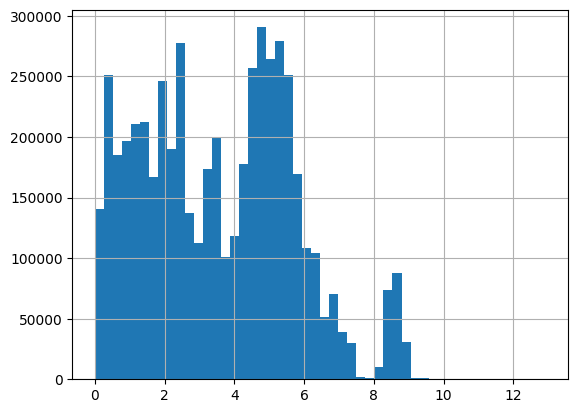

In [31]:
# 6-1. 누적 가동 시간을 24와 365로 나눠 age_yr에 담고 요약한다 (describe)
bb['age_yr'] = (bb['power_on_hours'] / 24)/365
bb['age_yr'].describe()
bb['age_yr'].hist(bins=50)

> 0년부터 12.9년까지, 중앙값 3.5년이다.

**6-2. 사용 기간이 정확히 1년인 디스크를 어느 구간에 넣을지 확인해 보자.**

나이별 고장률을 계산할 때 경계의 값을 중복해서 세거나 빠뜨리면 안 된다. 나이 0·0.5·1·1.5·2를 두 구간으로 나눠 본다.

`pd.cut`에 값과 경계 0·1·2를 준다. 기본적으로 오른쪽 경계를 포함하며, `include_lowest`를 True로 두면 첫 구간에 0도 포함한다.

In [34]:
# 6-2. 다섯 나이를 두 구간으로 나누고 경계의 소속을 확인한다 (Series, cut)
example_age = pd.Series([0,0.5,1,1.5,2])
example_age, pd.cut(example_age,[0,1,2], include_lowest=True)

(0    0.0
 1    0.5
 2    1.0
 3    1.5
 4    2.0
 dtype: float64,
 0    (-0.001, 1.0]
 1    (-0.001, 1.0]
 2    (-0.001, 1.0]
 3       (1.0, 2.0]
 4       (1.0, 2.0]
 dtype: category
 Categories (2, interval[float64, right]): [(-0.001, 1.0] < (1.0, 2.0]])

**6-3. 오래 사용한 디스크에서 고장이 더 자주 기록되는지 비교해 보자.**

나이마다 관측한 날수가 다르므로 구간별 고장 수를 관측한 날수로 나눠야 한다.

`pd.cut`으로 0부터 13년까지 1년 간격의 구간을 만들어 `age_bin`에 담는다. `groupby`와 `agg`로 구간별 데이터포인트 수 `days`와 고장 수 `fails`를 구해 `by_age`에 담는다. 고장 수를 관측한 날수로 나누고 365를 곱한 값을 `afr`에 추가한다. `observed`가 True이면 실제 관측된 구간만 집계한다.

/tmp/ipykernel_2790/1522885152.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_age = bb.groupby('age_bin').agg(days=("failure","size"), # 구간별 총 몇개,


<Axes: xlabel='age_bin'>

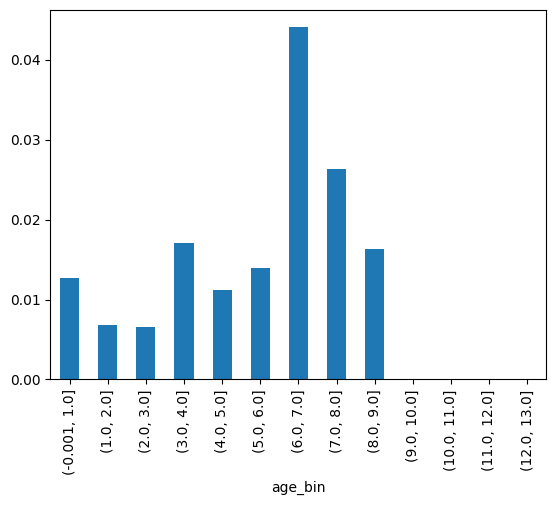

In [43]:
# 6-3. 나이를 1년 구간으로 나눠 구간별 days와 fails를 집계하고 afr을 추가한다. 첫 구간은 0도 포함한다 (cut, groupby, agg)
bb['age_bin'] = pd.cut(bb['age_yr'],  # 운용 연도를
                       range(0,14),   # 0~13까지 1년 구간으로 나눠라
                       include_lowest=True)
bb['age_bin']
by_age = bb.groupby('age_bin').agg(days=("failure","size"), # 구간별 총 몇개,
                                   fails=("failure","sum") # 구간별 고장 몇개
                                   )
by_age['afr'] = by_age['fails']/by_age['days']*365 # 고장 빈도
by_age['afr'].plot(kind='bar')

> 첫 해의 연간고장률은 약 0.013, 1∼3년은 약 0.007, 6∼7년은 약 0.044다. 9년 이상은 관측된 날수가 적다.

나이별 고장 빈도는 다르지만, 이 표는 서로 다른 디스크를 같은 분기에 비교한 결과다. 같은 디스크의 평생 위험이 욕조곡선을 따른다고 확인한 것은 아니다. 모델과 투입 시기의 차이도 섞여 있으며, 나이 기준 교체의 비용 효과는 8절에서 따로 센다.

## 7. 계획 ③ — 신호가 고장 전에 미리 켜지는가

나이보다 개별 디스크의 상태가 고장에 가까운 정보를 주는지 살펴본다. 불량 섹터와 오류를 기록하는 네 지표를 신호로 쓰며, 0보다 크면 켜진 것으로 본다. 고장이 기록된 디스크에서 더 자주 켜져 있는지 확인한 뒤, 실제로 고장 전에 관측됐는지를 구분한다.

**7-1. 각 디스크에서 마지막으로 관측한 상태를 하나씩 골라 보자.**

고장 여부에 따른 상태 차이를 비교하려면 디스크마다 한 행을 골라야 한다. 먼저 그룹 a·a·b와 값 1·2·3을 담은 표에서 확인한다.

`groupby`로 그룹을 묶고 `tail`에 1을 지정하면 그룹별 마지막 행이 남는다. 시간상 마지막 행을 고를 때는 날짜 순으로 먼저 정렬해야 한다.

In [47]:
# 7-1. 그룹마다 마지막 행만 남긴다 (groupby 뒤 tail(1))
tiny = pd.DataFrame({'g':['a','a','b','b'],'x':[1,2,3,7]})
tiny.groupby('g').tail(1)

,g,x
1,a,2
3,b,7


**7-2. 디스크의 마지막 상태와 관측된 고장 여부를 연결해 보자.**

고장 디스크의 마지막 기록에는 고장 당일 정보가 포함된다. 고장 미기록 디스크의 마지막 관측일도 반드시 3월 31일은 아니다. 따라서 이 표는 마지막 상태의 차이를 보는 자료다.

네 신호의 열 이름을 `SIGNALS`에 담는다. 날짜로 정렬한 뒤 디스크별 마지막 행을 골라 `last_day`에 담고, `set_index`로 디스크 번호를 인덱스로 둔다. 인덱스가 `failed`에 들어 있는지 `isin`으로 확인해 `is_fail`에 담는다.

In [61]:
# 7-2. 네 신호 이름을 SIGNALS에 담고 디스크별 마지막 관측 last_day에 고장 기록 여부 is_fail을 붙인다 (sort_values, groupby, tail, set_index, isin)
SIGNALS = ['reallocated_sectors','uncorrectable_errors','pending_sectors','offline_uncorrectable'] # 상태를 모니터 할 지표
last_day = bb.sort_values('date').groupby('serial_number').tail(1).set_index('serial_number')

In [62]:
last_day['is_fail'] = last_day.index.isin(failed) # 여기에 기록된 각각의 하드디스크가 고장이 났는지 여부
last_day

,date,model,capacity_tb,failure,reallocated_sectors,power_on_hours,uncorrectable_errors,command_timeouts,pending_sectors,offline_uncorrectable,age_yr,age_bin,is_fail
serial_number,,,,,,,,,,,,,
8CGKHZ5G,2026-01-02,HGST HUH721212ALE600,12.0,1,22,57308,-1,-1,7992,26,6.542009,"(6.0, 7.0]",True
2BJBEESN,2026-01-02,WDC WUH721816ALE6L4,16.0,1,0,26128,-1,-1,0,0,2.982648,"(2.0, 3.0]",True
ZA15YE4J,2026-01-02,ST8000NM0055,8.0,0,14064,73766,700,0,0,0,8.420776,"(8.0, 9.0]",False
8HJ98Z2H,2026-01-03,HGST HUH721212ALN604,12.0,1,53,58819,-1,-1,471,99,6.714498,"(6.0, 7.0]",True
1PG8S6AV,2026-01-03,WDC WUH722222ALE6L4,22.0,1,0,11529,-1,-1,16,0,1.316096,"(1.0, 2.0]",True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1RJWXX3G,2026-03-31,WDC WUH722222ALE6L4,22.0,0,0,12084,-1,-1,0,0,1.379452,"(1.0, 2.0]",False
Y2N0A016FVKG,2026-03-31,TOSHIBA MG08ACA16TA,16.0,0,0,20216,-1,-1,0,0,2.307763,"(2.0, 3.0]",False
21HZZPSN,2026-03-31,WDC WUH722222ALE6L4,22.0,0,0,7512,-1,-1,0,0,0.857534,"(-0.001, 1.0]",False


> 194다.

**7-3. 고장이 기록된 디스크에서 어떤 신호가 더 자주 보이는지 비교해 보자.**

신호별로 두 집단의 켜진 비율을 비교한다. 이 단계의 고장 당일 정보를 앞으로의 예측에 사용할 수 있다는 뜻은 아니다.

`for`로 신호를 하나씩 고르고, `is_fail` 조건에 따라 마지막 기록을 나눈다. 신호가 0보다 큰지 비교한 참·거짓의 `mean`이 켜진 비율이다. 두 비율과 그 배수를 사전으로 만들고 `append`로 `rows`에 모아 `DataFrame`으로 표시한다.

In [63]:
# 7-3. 신호마다 고장 기록 유무별 켜진 비율과 그 배수를 rows에 모아 표로 비교한다 (for, loc, mean, append, DataFrame)
rows = []
for c in SIGNALS:
  f = (last_day[last_day['is_fail']][c] >0).mean() # 고장난 디스크의 마지막 날 각각의 상태가 양수일 비율
  o = (last_day[~last_day['is_fail']][c] >0).mean() # 고장이 안 난 디스크의 마지막 날 각각의 상태가 양수일 비율
  rows.append({'signal' :c, 'failed':f,'healthy':o,'ratio':f/o})
pd.DataFrame(rows).round(3)

,signal,failed,healthy,ratio
0,reallocated_sectors,0.619,0.055,11.259
1,uncorrectable_errors,0.284,0.016,17.442
2,pending_sectors,0.644,0.022,29.519
3,offline_uncorrectable,0.423,0.015,28.213


> 대기 불량 섹터 신호는 고장 디스크의 약 0.64, 고장이 기록되지 않은 디스크의 약 0.02에서 켜져 있다. 신호별 비율의 배수는 약 11∼30이다.

고장이 기록된 디스크에서 신호가 더 자주 보인다. 다만 고장 당일 정보가 포함된 비교이므로, 이 배수가 고장 전 예측 성능이나 신호가 있는 디스크의 고장 확률을 뜻하지는 않는다.

**7-4. 신호가 교체할 시간을 주었는지 알아볼 수 있도록 고장까지 남은 날수를 계산해 보자.**

고장 당일의 신호와 며칠 전의 신호를 나눠 보려면 각 기록이 고장 며칠 전인지 알아야 한다.

고장 기록의 디스크 번호를 `set_index`로 인덱스에 두고 날짜 열을 골라 `fail_date`를 만든다. 고장 집합에 속한 디스크의 기록을 `fd`에 담고, `map`으로 붙인 고장 날짜에서 기록 날짜를 뺀다. `dt.days`로 일 단위 값을 꺼내 `days_to_fail`에 담는다.

In [65]:
# 7-4. 디스크별 고장 날짜 fail_date를 고장 디스크 기록 fd에 대응시키고 고장까지 남은 날수 days_to_fail을 구한다 (set_index, isin, map, dt.days)
bb[bb['failure']==1].set_index('serial_number')['date']
fail_date=bb['serial_number'].isin(failed) #고장이 난 날짜
fail_date

,serial_number
630,False
631,False
632,False
633,False
634,False
...,...
5226048,False
5226049,False
5226050,False
5226051,False


In [76]:
fd=bb[bb['serial_number']].isin(failed).copy # 전체 데이터에서 고장이 난 시리얼 넘버를 가진 기록들만 다 추리고 싶음
fd
fd['days_to_fail'] = (fd['serial_number'].map(fail_date) - fd['date']).dt.days # 고장 시리얼 일자 기록 각각에 대하여 고장까지 남은 날수
fd[['serial_number','date','days_to_fail']]

KeyError: "None of [Index(['1030A00KF97G', '1030A00KF97G', '1030A00KF97G', '1030A00KF97G',\n       '1030A00KF97G', '1030A00KF97G', '1030A00KF97G', '1030A00KF97G',\n       '1030A00KF97G', '1030A00KF97G',\n       ...\n       'ZYDDR339', 'ZYDDR339', 'ZYDDR339', 'ZYDDR339', 'ZYDDR339', 'ZYDDR339',\n       'ZYDDR339', 'ZYDDR339', 'ZYDDR339', 'ZYDDR339'],\n      dtype='object', length=5221794)] are in the [columns]"

**7-5. 고장 당일뿐 아니라 며칠 전에도 신호가 관측되는지 살펴보자.**

당일, 1~7일 전, 8~30일 전, 31~90일 전으로 나눠 관측된 신호 비율을 읽는다. 하루·일주일·한 달 정도 앞선 모습을 구분하기 위한 요약 구간이며 교체 기준은 아니다.

`between`으로 양 끝을 포함한 기간 조건을 만들고, 각 신호가 양수인지 비교한 평균을 구한다. 네 신호 중 하나라도 참인지 보려면 `any`의 `axis`를 1로 둔다. 결과를 사전 `cols`에 모아 표로 만든다. 마지막 열의 고장 미기록 디스크는 마지막 관측 한 건씩이며, 앞 열의 고장 디스크는 해당 구간의 여러 데이터포인트다.

> **교수자 시연.** 반복 계산을 읽고, 표의 각 비율이 무엇을 분모로 하는지 설명한다.

In [75]:
# 7-5. 고장까지 남은 날수 구간별로 각 신호와 하나 이상 켜진 비율을 cols에 모은다. 고장 미기록 디스크의 마지막 상태도 비교한다 (between, any, mean, DataFrame)
cols = {}
for lo, hi in [(0,0),(1,7),(8,30),(31,90)]:
    sub = fd[fd['days_to_fail'].between(lo,hi)] #고장난 디스크이 고장까지의 날수를 구간별로 나누어서
    on = (sub[SIGNALS]>0).mean() # 4개의 지표에 대해 양수인 비율
    on['any of 4'] = (sub[SIGNALS]>0).any(axis=1).mean() # 4개 지표 중 하나라도 양수인 비율
    cols[f'{lo}-{hi} days before']= on


KeyError: 'days_to_fail'

In [ ]:
ok = last_day[~last_day['is_fail']] # 고장이 안난 드라이브를 고른다
on = (ok[SIGNALS]>0).mean() # 고장이 안 난 드라이브에서 4개 지표가 양수일 비율
on['any of 4'] = (ok[SIGNALS]>0).any(axis=1).mean() # 고장이 안난 드라이브에서 4개중 하나라도 고장이 안날 비유
cols['healthy'] = on
pd.DataFrame(cols).round(3)

> 대기 불량 섹터가 켜진 비율은 고장 31∼90일 전 약 0.46, 8∼30일 전 약 0.55, 1∼7일 전 약 0.57, 당일 약 0.64다. 당일에도 네 신호가 모두 꺼진 고장 디스크가 약 0.22다.

구간별 값은 그 구간에 관측된 데이터포인트의 비율이다. 같은 디스크가 여러 날 기여하고 구간마다 포함되는 디스크도 다를 수 있으므로, 모든 디스크의 신호가 같은 경로로 변했다고 읽지는 않는다.

**7-6. 처음 관측한 신호부터 고장까지 며칠의 여유가 있었는지 확인해 보자.**

고장 전에 신호가 관측된 디스크를 대상으로 한다. 신호가 실제로 처음 발생한 시점과 기록에서 처음 발견한 시점은 다를 수 있다.

`fd`에서 고장까지 1일 이상 남았고 `pending_sectors`가 양수인 기록을 고른다. 디스크별 `days_to_fail`의 `max`가 가장 이른 신호 관측에서 남은 날수다. 이를 `lead`에 담고 `describe`와 7일 이하인 조건의 합으로 확인한다.

In [ ]:
# 7-6. 고장 전 양수 신호가 관측된 디스크별 남은 날수의 최댓값 lead를 요약하고 7일 이하 개수를 센다 (조건 필터, groupby, max, describe)

**7-7. 기록이 시작될 때부터 신호가 켜져 있던 디스크가 얼마나 되는지 확인해 보자.**

이 경우 실제 신호 발생은 첫 관측보다 앞설 수 있다. 선행 시간을 기록에서 확인한 범위로 해석해야 한다.

날짜순으로 정렬하고 디스크별 `head`에 1을 지정해 첫 행을 고른다. 디스크 번호를 인덱스로 둔 `first_fd`에서 `loc`으로 `lead`에 포함된 디스크를 고르고, 대기 불량 섹터가 양수인 개수를 센다.

In [ ]:
# 7-7. 신호가 고장 전에 관측된 디스크 중 첫 관측부터 양수였던 개수를 센다 (sort_values, groupby, head, set_index, loc, sum)

> 고장 전에 신호가 관측된 120개 디스크에서 고장까지 남은 날수의 중앙값은 38.5일이고, 7일 이하는 14개다. 86개는 첫 관측부터 신호가 켜져 있었다.

86개의 신호 발생 시점은 처음 관측한 날 또는 그보다 앞일 수 있다. 따라서 이 값은 처음 관측한 신호부터 고장까지의 시간이며 실제 발생 시점부터의 시간은 더 길 수 있다. 교체에 7일이 걸린다면 남은 날수가 7일 이하인 사례는 완료 시점과 고장 시각을 더 확인해야 한다.

## 8. 계획 ④ — 규칙대로 했다면 몇 개를 바꾸고 몇 건을 막았을까

이 90일 동안 규칙을 도입했다면 교체할 디스크와 예방 가능한 고장을 센다. 매일 기록을 확인해 조건에 처음 걸린 날 교체하고, 같은 디스크는 한 번만 센다. 처음 관측될 때 이미 조건에 걸려 있으면 그날 교체한다. 중간에 관측이 시작된 디스크도 같은 방식으로 판단한다.

교체 대상 전체를 $n$, 그중 이 기간에 실제 고장이 기록된 디스크를 $m$으로 둔다. 처음부터 조건에 걸린 디스크와 이후 새로 걸린 디스크를 구분해 보여 주지만 비용에는 모두 포함한다.

가정: 조건을 확인한 날 교체를 완료하며, 교체한 디스크의 고장은 예방하고 새 디스크는 남은 기간에 고장 나거나 다시 교체되지 않는다고 본다. 고장 당일에 처음 걸리면 예방할 수 없는 것으로 처리한다. 7절에서 관측한 선행 시간이 실제 교체 시간보다 짧으면 이 가정이 성립하지 않을 수 있다. 여기서 예방 가능한 고장은 교체 실험으로 확인한 효과가 아니라 이 가정 아래 예방 대상으로 포함한 관측 고장이다. 이 결과는 과거 기록에 적용한 비교이며 장기 운영비의 추정은 아니다.

**8-1. 고장이 나기 전에 교체를 판단할 수 있었던 기록을 남겨 보자.**

고장 당일에야 처음 켜진 신호로는 예방했다고 셀 수 없다. 고장 미기록 디스크는 관측된 기록을 모두 사용한다.

`fail_date`를 디스크 번호에 `map`해 `fdate`에 담는다. 고장 날짜가 비어 있거나 기록 날짜가 고장 날짜보다 앞선 행을 `before`에 담는다. `isna`와 두 조건 중 하나를 만족하는 `|`를 사용한다.

In [80]:
# 8-1. 고장 날짜를 대응시켜 고장 전 기록과 고장 미기록 디스크의 기록을 before에 담는다 (map, isna, 조건 필터)
fdate = bb['serial_number'].map(fail_date)
before = bb[bb['failure']==0] # 고장날짜가 비어있거나, 고장전에 살아있던 기록이
before

,date,serial_number,model,capacity_tb,failure,reallocated_sectors,power_on_hours,uncorrectable_errors,command_timeouts,pending_sectors,offline_uncorrectable,age_yr,age_bin
630,2026-01-01,1030A00KF97G,TOSHIBA MG07ACA14TA,14.0,0,0,44487,-1,-1,0,0,5.078425,"(5.0, 6.0]"
631,2026-01-02,1030A00KF97G,TOSHIBA MG07ACA14TA,14.0,0,0,44503,-1,-1,0,0,5.080251,"(5.0, 6.0]"
632,2026-01-03,1030A00KF97G,TOSHIBA MG07ACA14TA,14.0,0,0,44534,-1,-1,0,0,5.083790,"(5.0, 6.0]"
633,2026-01-04,1030A00KF97G,TOSHIBA MG07ACA14TA,14.0,0,0,44566,-1,-1,0,0,5.087443,"(5.0, 6.0]"
634,2026-01-05,1030A00KF97G,TOSHIBA MG07ACA14TA,14.0,0,0,44581,-1,-1,0,0,5.089155,"(5.0, 6.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5226048,2026-03-27,ZYDDR339,ST24000NM002H,24.0,0,0,137,0,0,0,0,0.015639,"(-0.001, 1.0]"
5226049,2026-03-28,ZYDDR339,ST24000NM002H,24.0,0,0,168,0,0,0,0,0.019178,"(-0.001, 1.0]"
5226050,2026-03-29,ZYDDR339,ST24000NM002H,24.0,0,0,183,0,0,0,0,0.020890,"(-0.001, 1.0]"
5226051,2026-03-30,ZYDDR339,ST24000NM002H,24.0,0,0,214,0,0,0,0,0.024429,"(-0.001, 1.0]"


> 5,221,600개다. 고장 난 날의 데이터포인트 194개가 빠졌다.

**8-2. 처음 관측부터 교체해야 할 디스크를 구별할 수 있도록 첫 기록을 골라 보자.**

처음부터 조건에 걸린 디스크도 교체 비용에 포함한다. 이후 새로 조건에 걸린 디스크와 구분해 교체 부담을 읽는다.

`before`를 날짜로 정렬한 뒤 디스크별 `head`에 1을 지정해 첫 행을 `first`에 담는다. 첫 관측일은 디스크마다 다를 수 있다. 원래 행 인덱스는 그대로 남긴다.

In [81]:
# 8-2. 고장 전 기록에서 디스크별 첫 관측 first를 만들고 행 수를 확인한다 (sort_values, groupby, head, len)
first = before.sort_values('date').groupby('serial_number').head(1) # 고장전
 기록에서 첫 기록된 날짜별 기록만 추림
len(first)

59927

**8-3. 교체 대상 중 실제 고장이 기록된 디스크가 몇 개인지 세어 보자.**

교체 대상이 A·B·C이고 관측 고장 디스크가 B·C·D라면 교체는 3개, 겹치는 고장은 B·C의 2개다. 즉시 교체로 이 고장을 막을 수 있다고 가정한다.

두 집합 모두에 있는 원소를 교집합이라 한다. `&`로 교집합을 구하고 `len`으로 교체 집합과 교집합의 크기를 센다.

In [ ]:
# 8-3. 교체 대상 A·B·C와 고장 디스크 B·C·D의 공통 원소를 세어 전체 교체와 비교한다 (set, 교집합, len)

**8-4. 대기 불량 섹터가 있으면 교체하는 규칙의 교체 부담과 예방 대상을 계산해 보자.**

여러 날 신호가 켜져도 디스크는 한 번만 교체한다. 처음 관측부터 조건에 걸린 디스크도 전체 교체 비용에 포함한다.

고장 전 기록의 양수 신호 조건을 `cond`에 담고, 해당 디스크 번호를 집합 `idx`에 모은다. 첫 관측 표에서도 같은 조건으로 집합 `initial`을 만든다. `len`으로 전체 교체 `n`과 고장 집합과의 교집합 `m`을 세고, 처음과 이후의 교체 개수 및 `n/m`을 확인한다.

In [85]:
# 8-4. 고장 전 대기 불량 섹터가 0보다 큰 디스크 집합 idx와 첫 관측에서 걸린 집합 initial을 만든다. 전체 교체 n과 고장 집합의 교집합 m을 센다 (조건 필터, set, len)
cond = before['pending_sectors']>0
idx = set(before[cond]['serial_number']) # pending sectors가 양수인 하드디스크의 시리얼 넘버
initial = set(first[first['pending_sectors']>0]['serial_number'])
n = len(idx)
m = len(set(failed) & idx)
n, len(initial), n - len(initial), m, n/m


(1683, 1192, 491, 120, 14.025)

> 교체 대상 1,683개 중 첫 관측부터 걸린 것은 1,192개, 이후 새로 걸린 것은 491개다. 예방 가능한 고장은 120건이고, 고장 하나당 전체 교체는 14.0개다.

첫 관측은 디스크마다 다르므로 첫 관측 교체가 모두 1월 1일에 일어나는 것은 아니다. 전체 교체와 예방 가능한 고장을 같은 디스크 집합에서 센 뒤 다른 규칙과 비교한다.

**8-5. 신호를 넓게 보거나 나이와 함께 보면 교체 대상이 어떻게 달라지는지 비교해 보자.**

나이 규칙은 5·6·7년으로 경계를 옮기고, 신호 규칙은 대기 불량 섹터에서 오류·네 신호 전체로 대상을 넓힌다. 나이 4년 초과와 신호를 함께 요구하는 후보는 대상을 좁히는 예다. 이 값들은 비교용 후보이며 현장 권고 기준이나 최적값으로 확인한 것은 아니다.

규칙 이름을 키, 데이터포인트별 조건을 값으로 하는 사전 `rules`를 만든다. `|`는 둘 중 하나, `&`는 둘 다 만족하는 조건이며 비교식은 괄호로 묶는다. 네 신호 중 하나라도 양수인 조건은 `any`로 구한다.

In [ ]:
# 8-5. 규칙 이름과 before의 조건을 rules에 담는다. 나이 기준과 신호 조합을 비교한다 (for, 사전, 비교, any)
rules = {}
for T in (5,6,7):
    rules[f"age > : {T}"] = before['age_yr'] > T
rules['pendine>0 =']=before['pending_sectors'] > 0
rules['pending>0 or uncorrectable'] = (before['pending_sectors']>0) | (before['uncorrectable_errors']>0)
rules['any of 4>0'] = (before[SIGNALS]>0).any(axis=1)
rulse['penidng']


**8-6. 규칙마다 교체할 디스크와 예방 대상으로 포함한 고장을 한 표에서 비교해 보자.**

규칙마다 같은 기록과 같은 집계 방식을 써야 교체와 고장의 수를 비교할 수 있다.

`items`로 규칙 이름과 조건을 하나씩 꺼낸다. 조건을 만족한 디스크 집합과 첫 관측부터 만족한 집합을 만들고, 전체 교체 `hit`·첫 관측 교체 `initial`·이후 교체 `new`·고장 집합과 겹치는 `prevented`를 `rows`에 모은다. 이 목록을 `DataFrame`으로 바꿔 `rule_tbl`에 담는다. `cond`는 원래 행 인덱스를 가진 조건이므로, `loc`에 `first.index`를 지정하면 첫 관측 행의 조건만 고를 수 있다.

In [88]:
# 8-6. 규칙별 전체·첫 관측·이후 교체와 예방 대상 고장 수를 rows에 모아 rule_tbl을 만든다 (items, set, append, DataFrame)
rows = []
for name, cond in rules.items():
    idx = set(before[cond]['serial_number'])
    initial = set(first[first['serial_number'].isin(idx)]['serial_number'])
    n = len(idx) # 각각의 룰에 걸리는 개수
    m = len(set(failed) & idx) # 예방할 수 있었던 고장난 하드디스크의 개수
    rows.append({'rule':name, 'hit':n, 'initial':len(initial), 'new':n - leb(initial), 'prevented': m})
rule_tbl = pd.DataFrame(rows)
rule_tbl

NameError: name 'rules' is not defined

**8-7. 고장 하나를 예방 대상으로 포함하는 데 몇 개를 교체하는지 비교해 보자.**

교체 개수가 적어도 예방 대상으로 포함한 고장이 적으면 유리하다고 단정할 수 없다. 두 수의 비율과 남은 고장 수를 함께 확인한다.

전체 관측 고장에서 `prevented`를 뺀 값을 `not_prevented`에 담는다. `hit`를 `prevented`로 나눈 값을 `per_failure`에 담고, 예방 대상이 0이면 `loc`으로 해당 행을 골라 `np.inf`로 표시한다. 비율이 작은 순서로 정렬하고 `reset_index`의 `drop`을 True로 두어 새 행 번호를 붙인다.

In [ ]:
# 8-7. 남은 고장과 고장 하나당 교체를 계산하고 비율 순으로 정렬한다. 예방 대상이 0이면 무한대로 표시한다 (loc, sort_values, reset_index)

> 신호를 쓰는 규칙의 고장 하나당 교체 개수는 13.0∼30.9개, 나이 규칙은 144.6∼256.4개다. 가장 많은 고장을 포함하는 규칙도 49건은 예방 대상으로 잡지 못한다.

고장 하나당 교체 개수가 작아도 예방 가능한 고장 수가 작으면 남은 고장의 비용이 클 수 있다. 후보를 고르려면 교체와 고장 후 대응의 비용을 함께 비교해야 한다.

### 💬 생각해보기

나이와 신호를 결합한 규칙은 교체 개수가 적지만 예방 가능한 고장도 적다. 고장 후 대응 비용이 커질 때도 이 규칙이 가장 싼가.

## 9. 계획 ⑤ — 비용 비율에 따라 어느 규칙이 이득인가

교체할 디스크 전체와 예방 가능한 고장을 비용으로 비교한다. 미리 교체하는 비용을 $C_p$, 고장 후 대응 비용을 $C_f$라 하면 규칙의 비용은 전체 교체에 드는 비용과 남은 고장에 대응하는 비용의 합이다. 고장 후 교체만 하는 경우에는 관측된 고장 194건 모두에 $C_f$가 든다. 처음 관측부터 조건에 걸린 디스크의 교체 비용도 포함한다.

금액은 이 데이터에 없으므로 비용 차이가 작은 경우와 큰 경우를 가정해 비교한다. 아래 금액은 실제 Backblaze의 비용이나 시장 가격을 추정한 값이 아니다. $C_f$에는 교체·작업·서비스 중단 등 회사가 부담하는 기대 비용이 포함되며, 그 구성은 회사에서 확인해야 한다.

**경우 1. 가정: 계획 교체와 고장 후 대응 비용이 비슷한 경우.** 계획 교체는 40만 원, 고장 후 대응은 45만 원으로 둔다. 비율은 1.125다.

**9-1. 고장 후 대응 비용이 계획 교체와 비슷해도 미리 바꾸는 것이 이득인지 비교해 보자.**

교체 부담과 남은 고장의 비용을 합쳐야 한다.

`rule_tbl`에서 규칙·전체 교체·남은 고장 열의 사본을 `case1`에 담는다. 전체 교체에 계획 교체 비용을 곱하고 남은 고장의 대응 비용을 더해 `cost`를 만든다. 고장 후 교체만 하는 비용으로 나눈 값을 `ratio`에 담는다.

In [ ]:
# 9-1. 계획 교체 40만 원과 고장 후 대응 45만 원을 CP와 CF에 두고 전체 교체와 남은 고장의 총비용 cost 및 상대 비용 ratio를 구한다 (copy, 사칙연산)

> 고장 후 교체 비용은 8,730만 원이다. 대기 불량 섹터 규칙은 70,650만 원으로 8.09배다.

이 비용 가정에서는 비교한 예방 교체 규칙 모두 고장 후 교체보다 비싸다. 처음부터 조건에 걸린 디스크도 바꿔야 하므로 전체 교체 비용을 포함해 판단한다.

**경우 2. 가정: 고장 후 대응 비용이 큰 경우.** 계획 교체는 45만 원, 고장 후 대응은 750만 원으로 둔다. 비율은 약 16.7이다.

**9-2. 고장 후 대응 비용이 커지면 선택도 달라지는지 비교해 보자.**

앞에서 제시한 두 번째 비용 가정으로 계산한다.

계획 교체 비용은 45만 원, 고장 후 대응 비용은 750만 원으로 두고, 9-1과 같은 계산을 `case2`에 담는다. 두 비용이 모두 바뀌지만 상대 비용 비교를 정하는 것은 두 비용의 비율이다.

In [ ]:
# 9-2. 계획 교체 45만 원과 고장 후 대응 750만 원으로 전체 교체 및 남은 고장 비용을 다시 비교한다 (copy, 사칙연산)

> 고장 후 교체 비용은 145,500만 원이다. 대기 불량 섹터 규칙은 0.90배, 정정 불가 오류까지 보는 규칙은 1.02배, 네 신호 중 하나라도 보는 규칙은 1.64배다.

이 가정에서는 대기 불량 섹터 규칙과 나이·신호 결합 규칙이 고장 후 교체보다 싸다. 신호를 더 많이 보는 규칙은 예방 가능한 고장이 늘어도 교체 비용이 더 커질 수 있다. 두 경우는 계획 교체 비용과 고장 후 대응 비용이 모두 다르며, 비교를 정하는 것은 그 비율이다.

**9-3. 어느 비용 조건에서 예방 교체가 고장 후 교체보다 싸지는지 비교해 보자.**

고장 후 대응 비용을 계획 교체 비용으로 나눈 비율을 R로 둔다. 비교할 R은 1·2·5·10·15·20·50·100이며 실제 비용을 안다는 뜻은 아니다.

규칙 이름을 인덱스로 한 표 `rt`를 만들고, `for`로 비용 비율을 바꾼다. 계획 교체 비용을 1로 두면 총비용은 전체 교체 개수에 R배의 남은 고장 수를 더한 값이다. 이를 고장 후 교체 비용인 R배의 194건으로 나누고 `cmp`의 열로 모은다.

In [ ]:
# 9-3. 규칙을 인덱스로 두고 각 비용 비율에서 전체 교체 및 남은 고장의 비용을 고장 후 교체 비용으로 나눠 cmp에 모은다 (set_index, DataFrame, for)

> 비교한 비용 비율 중 10까지는 모든 예방 교체 규칙의 상대 비용이 1보다 크다. 20에서는 일부 신호 규칙이 1보다 작고, 나이 규칙은 100에서도 1보다 크다.

이 90일의 도입 비용을 포함하면 신호 규칙의 손익분기 비율은 약 13.0∼30.9다. 고장 후 교체보다 싼지와 후보들 중 가장 싼지는 따로 판단해야 한다. 비교하지 않은 비용 비율에서는 최저 비용 후보가 바뀔 수 있으므로 표의 몇 열만으로 전체 구간의 순위를 단정하지 않는다. 이 범위와 순위는 기록의 기간, 교체 속도, 새 디스크에 대한 가정이 달라지면 바뀔 수 있다.

**9-4. 같은 교체 규칙인데도 비용 조건에 따라 판단이 달라지는 이유를 설명해 보자.**

대기 불량 섹터 규칙의 교체 개수와 예방 대상 고장 수는 고정하고 비용 비율만 바꾼다.

`R_TRY`를 5·20·50으로 바꿔 9-3의 상대 비용을 계산한다. 어느 조건에서 1보다 작은지 읽고 이유를 설명한다. 신호 기준값 0·1·4·16의 비교는 랩에서 이어서 한다.

In [ ]:
# 9-4. 비용 비율 R_TRY를 정하고 대기 불량 섹터 규칙의 전체 교체와 예방 고장으로 상대 비용을 구한다 (조건 필터, set, len)

### 💬 생각해보기

- 고장 하나당 교체 개수가 가장 적은 규칙과 총비용이 가장 적은 규칙은 왜 다를 수 있는가.
- 처음부터 신호가 켜진 디스크의 비용을 빼면서 그 고장의 예방 효과를 포함하면 비교가 어느 쪽으로 바뀌는가.
- 교체가 즉시 끝나지 않거나 새 디스크도 고장 난다면 지금 비용 비교는 어떻게 달라질 수 있는가.

## 10. 마무리

| 주제 | 핵심 |
|---|---|
| 대상 | 2026년 1분기 90일의 디스크 59,934개, 데이터포인트 5,221,794개, 고장 194건 |
| 고장 빈도 | 연간고장률 약 0.0136. 관측된 디스크·년당 고장 빈도이며 1년 고장 확률과 구분한다 |
| 신호 | 고장 당일의 신호 차이와 고장 전에 관측된 신호를 구분한다. 기록 시작부터 켜진 신호의 발생 시점은 알 수 없다 |
| 교체 집계 | 처음 관측부터 조건에 걸린 디스크도 전체 교체에 포함한다. 대기 불량 섹터 규칙은 1,683개 교체, 120건 예방 가능, 고장 하나당 14.0개 |
| 비용 판단 | 신호 규칙의 손익분기 비율은 약 13.0∼30.9. 전체 비용으로 후보를 비교하며 장기 운영비나 미래 성과로 확대하지 않는다 |

### 이번 주에 할 일

| 활동 | 자료 | 비고 |
|---|---|---|
| 배경이론 | 3주차 배경이론 문서 | 고장 빈도·예방정비·비용 비교 |
| 교재 실습 | 이 노트북 | 규칙의 교체 대상과 비용을 같은 기준으로 비교한다 |
| 랩 | `week03_lab.ipynb` — 같은 2026년 기록 | 교체 집합부터 기준값·비용 비교까지 계산 6과제와 본인의 판단·설명 1과제. 약 60분 |